### **Лабораторная работа по теме ARIMA №2**

**Задание:** В файле с данными по M3 competition  выбрать 3 ряда.

Подобрать модель ARIMA. Построить прогноз на 4 наблюдения вперед.

In [ ]:
!pip install pmdarima

In [2]:
# Импортируем необходимые для работы бибилиотеки
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from pandas import DataFrame
from sklearn.metrics import mean_absolute_percentage_error

In [3]:
# Загружаем данные
!gdown 12w5U86VTbBvsabUMLA00paLELQf7LRUJ

Downloading...
From: https://drive.google.com/uc?id=12w5U86VTbBvsabUMLA00paLELQf7LRUJ
To: /content/M3C.xls
100% 1.76M/1.76M [00:00<00:00, 77.9MB/s]


In [4]:
test = {}
train = {}
M3C = pd.ExcelFile ('/content/M3C.xls')
for sheet in 'M3Year M3Quart M3Month M3Other'.split():
    M3Year = M3C.parse(sheet).to_numpy()
    for row in M3Year:
        series = row[0]
        N = row[1]
        NF = row[2]
        train[series] = row[6:6+N-NF]
        test[series] = row[6+N-NF:6+N]

#### **Первый ряд - N 392**

In [5]:
df_1 = pd.DataFrame(train['N 392'])
df_1.head()

,0
0,4914.8
1,5071.4
2,4999.3
3,5175.8
4,5323.5


In [6]:
df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41 entries, 0 to 40
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       41 non-null     object
dtypes: object(1)
memory usage: 460.0+ bytes


In [7]:
# Переводим данные в числовой формат
df_1[0] = pd.to_numeric(df_1[0])

In [8]:
df_1.to_csv('M3_392.csv', columns=None, header=True)

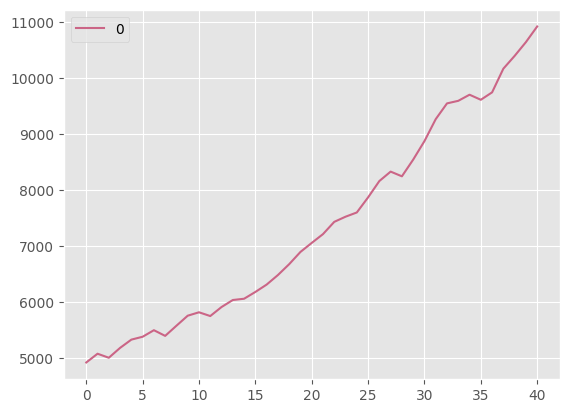

In [9]:
df_1.plot(color = '#CB6586')
plt.show()

По графику явно прослеживается восходящий тренд, ряд скорее всего не является стационарным.

Проверим стационарность ряда с помощью теста Дики-Фуллера.

In [ ]:
result_1 = adfuller(df_1[0])
print('ADF Statistic:', result_1[0])
print('p-value:', result_1[1])

if result_1[1] <= 0.05:
  print('Ряд стационарен')
else:
  print('Ряд нестационарен')

ADF Statistic: 2.1304064780345016
p-value: 0.9988201819809767
Ряд нестационарен


Построим графики ACF и PACF для подбора параметров модели ARIMA.

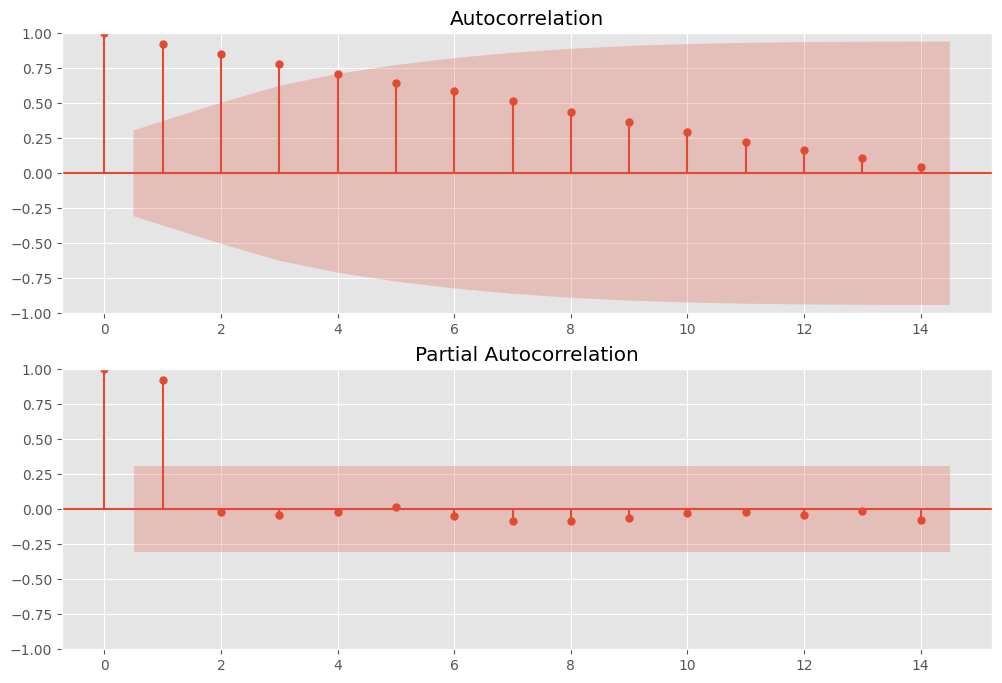

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df_1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(df_1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

По графику видно, что:

*   ACF убывает медленно и не обрывается резко, это является признаком нестационарного ряда -> d = 1
*   PACF показывает значимый пик только на лаге 1, после чего все значения попадают в доверительный интервал -> p = 1
*   Попробуем простые модели: ARIMA(1,1,0) и ARIMA(1,1,1).

In [ ]:
# Модель ARIMA(1,1,0)
model_1 = ARIMA(df_1, order=(1,1,0))
model_fit_1 = model_1.fit()
print(model_fit_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   41
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -255.270
Date:                Thu, 14 May 2026   AIC                            514.540
Time:                        13:57:14   BIC                            517.918
Sample:                             0   HQIC                           515.762
                                 - 41                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6820      0.152      4.490      0.000       0.384       0.980
sigma2      2.026e+04   4692.619      4.317      0.000    1.11e+04    2.95e+04
Ljung-Box (L1) (Q):                   2.38   Jarque-

In [ ]:
# Модель ARIMA(1,1,1)
model_2 = ARIMA(df_1, order=(1,1,1))
model_fit_2 = model_2.fit()
print(model_fit_2.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   41
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -250.588
Date:                Thu, 14 May 2026   AIC                            507.176
Time:                        13:53:36   BIC                            512.243
Sample:                             0   HQIC                           509.008
                                 - 41                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9945      0.019     53.534      0.000       0.958       1.031
ma.L1         -0.8841      0.126     -6.992      0.000      -1.132      -0.636
sigma2      1.552e+04   4236.880      3.664      0.0

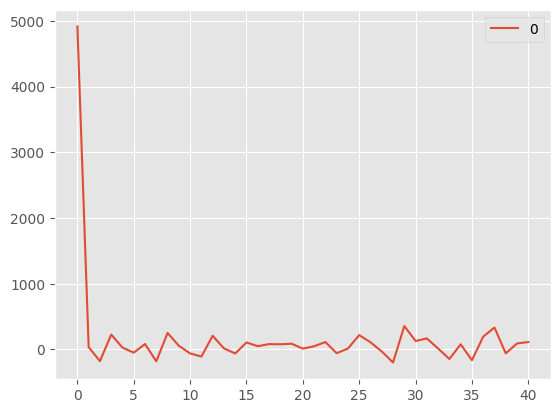

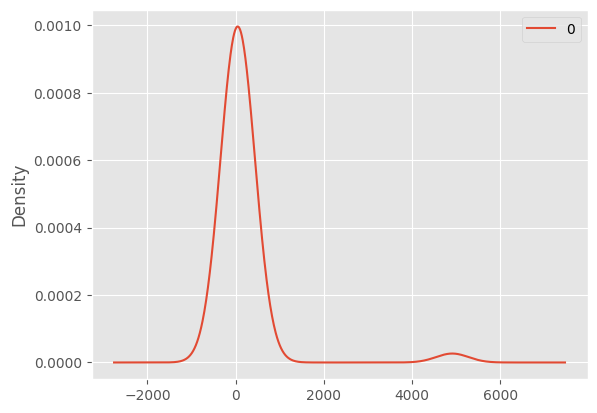

                 0
count    41.000000
mean    168.142330
std     771.397992
min    -199.021161
25%     -49.335048
50%      55.207910
75%     111.817317
max    4914.800000


In [ ]:
# Анализ остатков ARIMA(1,1,0)
residuals_1 = pd.DataFrame(model_fit_1.resid)
residuals_1.plot()
plt.show()

residuals_1.plot(kind='kde')
plt.show()
print(residuals_1.describe())

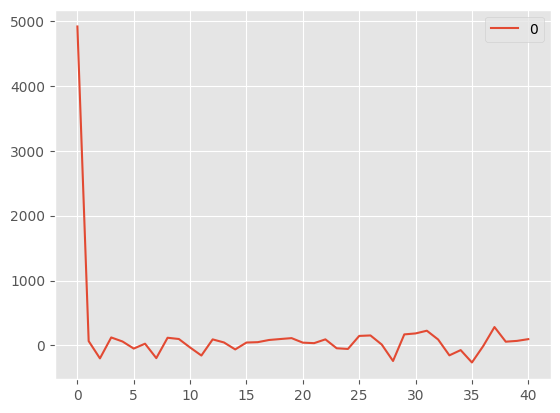

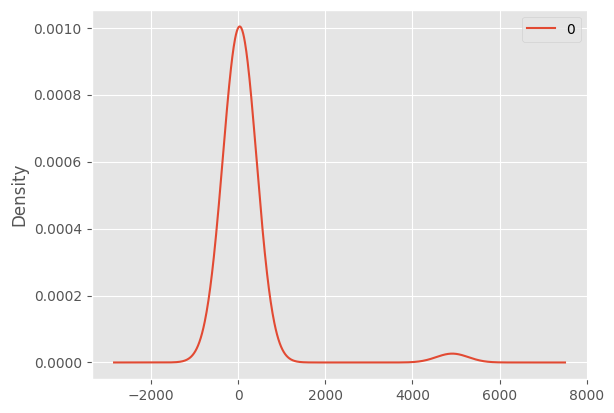

                 0
count    41.000000
mean    148.134186
std     772.903696
min    -262.766031
25%     -43.658804
50%      57.677262
75%      99.006292
max    4914.800000


In [ ]:
# Анализ остатков ARIMA(1,1,1)
residuals_2 = pd.DataFrame(model_fit_2.resid)
residuals_2.plot()
plt.show()

residuals_2.plot(kind='kde')
plt.show()
print(residuals_2.describe())

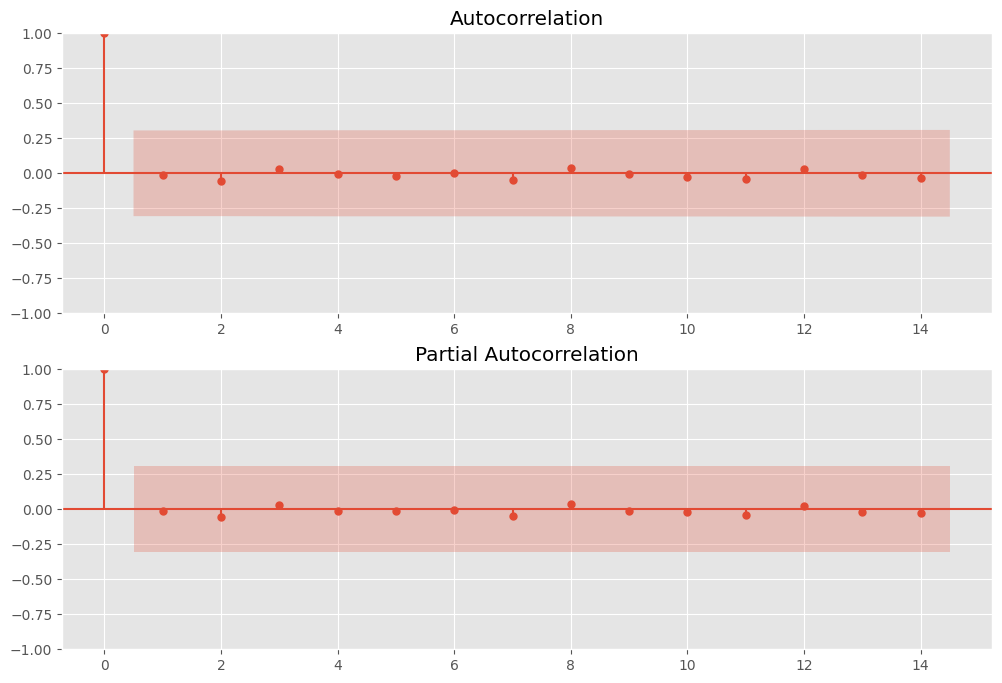

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

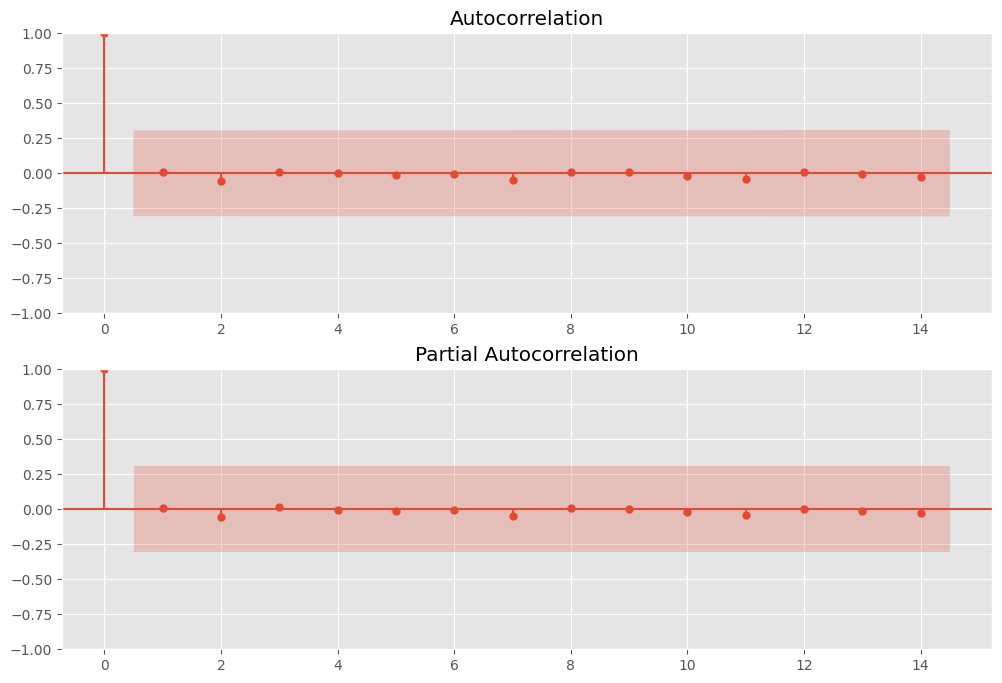

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_2, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_2, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [ ]:
# Сравнение моделей по AIC и BIC
comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,0)', 'ARIMA(1,1,1)'],
    'AIC': [model_fit_1.aic, model_fit_2.aic],
    'BIC': [model_fit_1.bic, model_fit_2.bic]})

comparison = comparison.sort_values('AIC')
print(comparison)

          Model         AIC         BIC
1  ARIMA(1,1,1)  507.176196  512.242835
0  ARIMA(1,1,0)  514.540226  517.917985


По результатам сравнения моделей выбираем ARIMA(1,1,1):

- Наименьшие AIC и BIC;
- Остатки во всех моделях ведут себя одинаково — ACF/PACF остатков не выявили структуры;
- Коэффициенты в ARIMA(1,1,1) статистически значимы.

Построим прогноз на 4 наблюдения вперед

MAPE = 4.24%


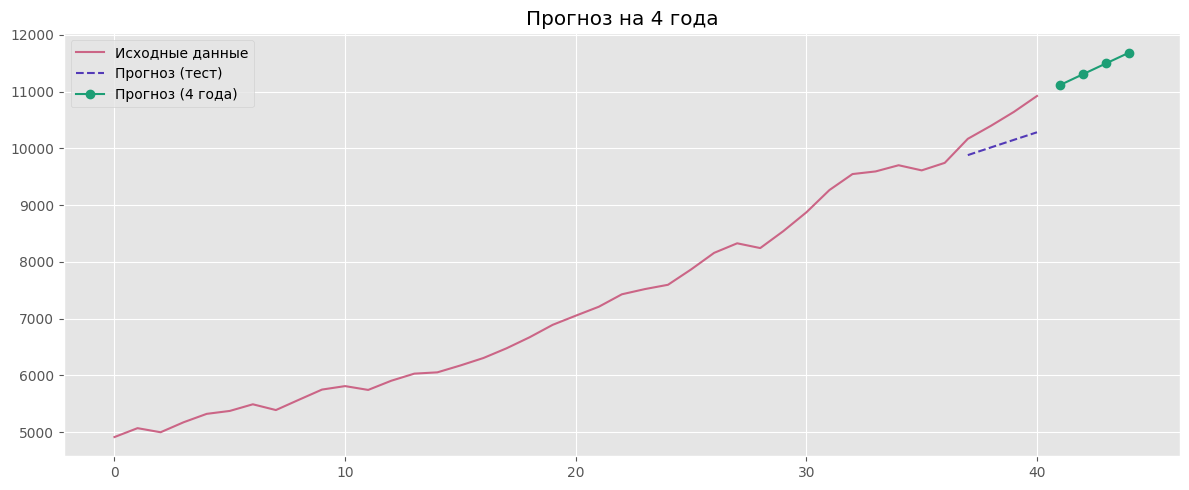

In [ ]:
# Разбивка на train/test (последние 4 наблюдения = тест)
train_1 = df_1.iloc[:-4]
test_1 = df_1.iloc[-4:]

# Обучаем модель на train
model_train = ARIMA(train_1, order=(1,1,1))
model_train_fit = model_train.fit()

# Прогноз на тестовый период
pred = model_train_fit.get_forecast(steps=4)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int(alpha=0.05)

# Метрика качества
mape = mean_absolute_percentage_error(test_1, pred_mean)
print(f'MAPE = {mape:.2%}')

# Переобучаем на всех данных → прогноз на 4 года вперёд
final_model = ARIMA(df_1, order=(1,1,1))
final_fit = final_model.fit()

forecast = final_fit.get_forecast(steps=4)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int(alpha=0.05)

# Визуализация
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df_1.index, df_1[0], color='#CB6586', label='Исходные данные')
ax.plot(test_1.index, pred_mean, '--', color='#533AB7', label='Прогноз (тест)')
ax.plot(fc_mean.index, fc_mean, 'o-', color='#1D9E75', label='Прогноз (4 года)')
ax.legend()
plt.title('Прогноз на 4 года')
plt.tight_layout()
plt.show()

In [ ]:
print('Прогноз на 4 наблюдения:')
print(fc_mean.round(2))

Прогноз на 4 наблюдения:
41    11115.98
42    11307.70
43    11498.37
44    11687.99
Name: predicted_mean, dtype: float64


По результатам тестирования модели ARIMA(1,1,1) на последних 4 наблюдениях
получили MAPE = 4.24%, что является высоким результатом для данного ряда.

Прогноз на 4 наблюдения вперёд соответствует восходящему тренду и сопоставим с предыдущими наблюдениями.

#### **Второй ряд - N 995**

In [ ]:
df_2 = pd.DataFrame(train['N 995'])
df_2.head()

,0
0,3736.5
1,3540.5
2,3596.0
3,3885.5
4,3845.0


In [ ]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       44 non-null     object
dtypes: object(1)
memory usage: 484.0+ bytes


In [ ]:
# Переводим данные в числовой формат
df_2[0] = pd.to_numeric(df_2[0])

In [ ]:
df_2.to_csv('M3_995.csv', columns=None, header=True)

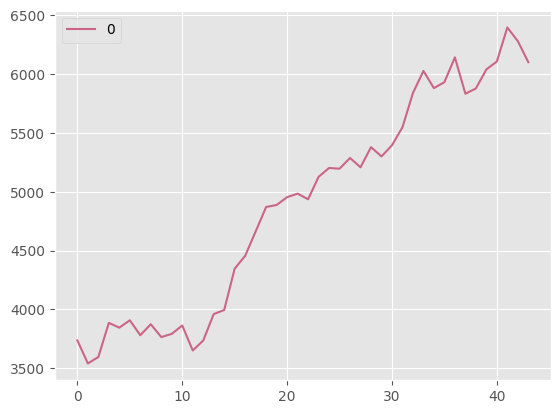

In [ ]:
df_2.plot(color = '#CB6586')
plt.show()

По график наблюдается восходящий тренд, а также небольшие локальные колебания. Ряд скорее всего является нестационарным.

Проверим стационарность ряда с помощью теста Дики-Фуллера.

In [ ]:
result_2 = adfuller(df_2[0])
print('ADF Statistic:', result_2[0])
print('p-value:', result_2[1])

if result_2[1] <= 0.05:
  print('Ряд стационарен')
else:
  print('Ряд нестационарен')

ADF Statistic: -0.44704260079738917
p-value: 0.9019431213415833
Ряд нестационарен


Построим графики ACF и PACF для подбора параметров модели ARIMA.

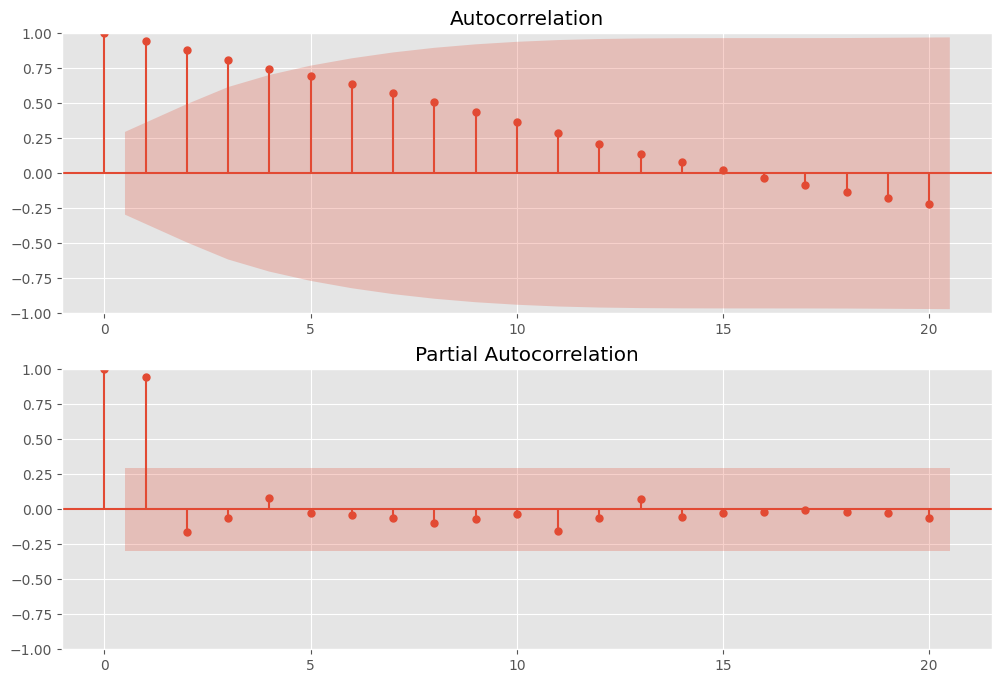

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df_2, lags=20, ax=plt.gca())
plt.subplot(212)

plot_pacf(df_2, method='ywmle', lags=20, ax=plt.gca())
plt.show()

По графику видно, что:

*   ACF убывает медленно и не обрывается резко, это является признаком нестационарного ряда -> d = 1
*   PACF показывает значимый пик только на лаге 1, после чего все значения попадают в доверительный интервал -> p = 1
*   Попробуем простые модели: ARIMA(1,1,1), ARIMA(1,1,0), ARIMA(0,1,1), ARIMA(0,1,0).



In [ ]:
# Модель ARIMA(1,1,1)
model_1 = ARIMA(df_2, order=(1,1,1))
model_fit_1 = model_1.fit()
print(model_fit_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   44
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -277.245
Date:                Thu, 14 May 2026   AIC                            560.491
Time:                        15:22:49   BIC                            565.774
Sample:                             0   HQIC                           562.439
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000      0.005    196.044      0.000       0.990       1.010
ma.L1         -0.9976      0.244     -4.095      0.000      -1.475      -0.520
sigma2      2.257e+04   1.11e-05   2.03e+09      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
# Модель ARIMA(1,1,0)
model_2 = ARIMA(df_2, order=(1,1,0))
model_fit_2 = model_2.fit()
print(model_fit_2.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   44
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -278.725
Date:                Thu, 14 May 2026   AIC                            561.449
Time:                        15:23:03   BIC                            564.972
Sample:                             0   HQIC                           562.748
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0526      0.181      0.291      0.771      -0.301       0.406
sigma2      2.494e+04   6523.906      3.823      0.000    1.22e+04    3.77e+04
Ljung-Box (L1) (Q):                   0.78   Jarque-

In [ ]:
# Модель ARIMA(0,1,1)
model_3 = ARIMA(df_2, order=(0,1,1))
model_fit_3 = model_3.fit()
print(model_fit_3.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   44
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -278.732
Date:                Thu, 14 May 2026   AIC                            561.464
Time:                        15:23:05   BIC                            564.987
Sample:                             0   HQIC                           562.763
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.0462      0.183      0.252      0.801      -0.313       0.406
sigma2      2.496e+04   6515.562      3.830      0.000    1.22e+04    3.77e+04
Ljung-Box (L1) (Q):                   0.72   Jarque-

In [ ]:
# Модель ARIMA(0,1,0)
model_4 = ARIMA(df_2, order=(0,1,0))
model_fit_4 = model_4.fit()
print(model_fit_4.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   44
Model:                 ARIMA(0, 1, 0)   Log Likelihood                -278.782
Date:                Thu, 14 May 2026   AIC                            559.564
Time:                        15:24:01   BIC                            561.325
Sample:                             0   HQIC                           560.214
                                 - 44                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2      2.505e+04   6458.476      3.878      0.000    1.24e+04    3.77e+04
Ljung-Box (L1) (Q):                   0.34   Jarque-Bera (JB):                 0.72
Prob(Q):                              0.56   Pr

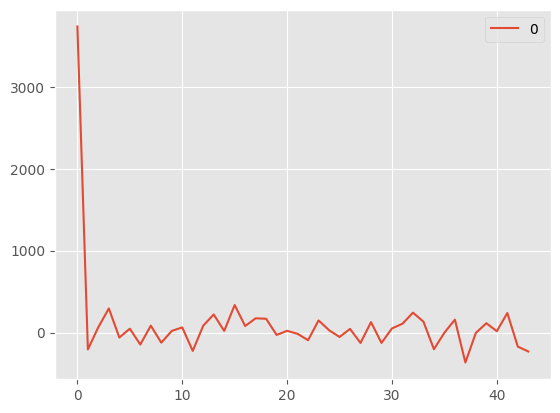

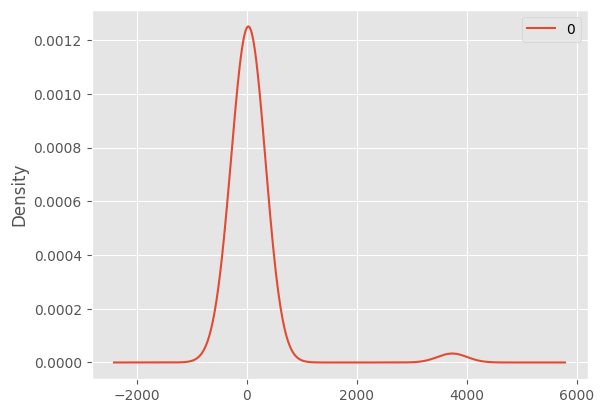

                 0
count    44.000000
mean    106.073509
std     580.075389
min    -364.617409
25%     -68.332465
50%      37.202384
75%     129.495309
max    3736.500000


In [ ]:
# Анализ остатков ARIMA(1,1,1)
residuals_1 = pd.DataFrame(model_fit_1.resid)
residuals_1.plot()
plt.show()

residuals_1.plot(kind='kde')
plt.show()
print(residuals_1.describe())

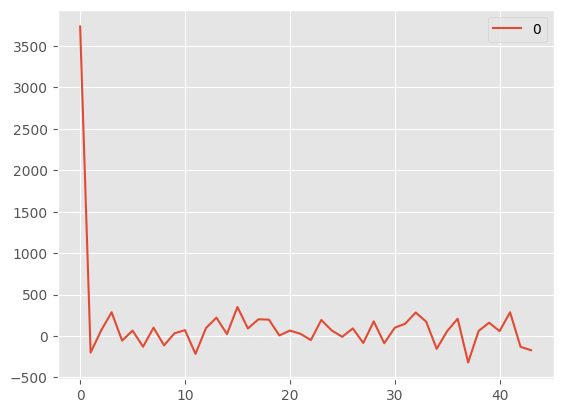

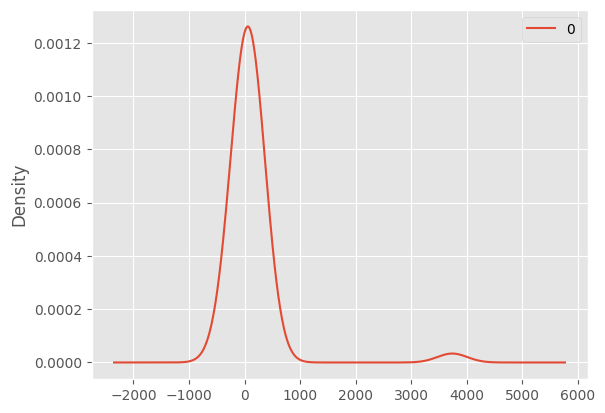

                 0
count    44.000000
mean    135.523046
std     575.219590
min    -320.064493
25%     -51.111906
50%      65.546598
75%     173.072832
max    3736.500000


In [ ]:
# Анализ остатков ARIMA(1,1,0)
residuals_2 = pd.DataFrame(model_fit_2.resid)
residuals_2.plot()
plt.show()

residuals_2.plot(kind='kde')
plt.show()
print(residuals_2.describe())

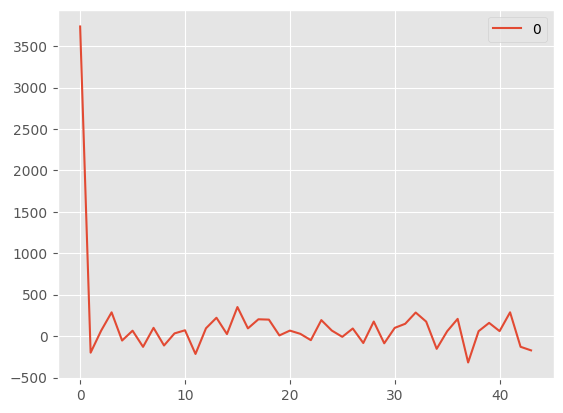

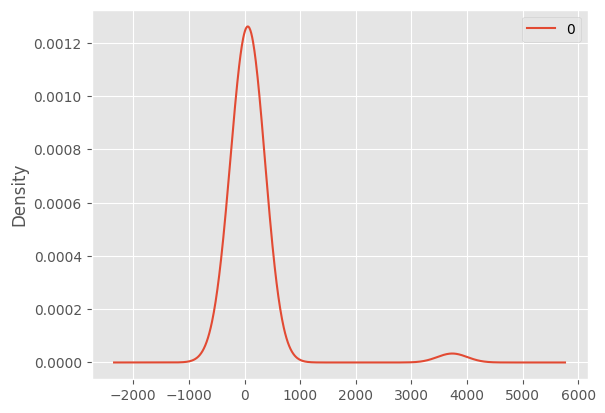

                 0
count    44.000000
mean    136.029858
std     575.104571
min    -318.609075
25%     -50.371282
50%      65.561933
75%     174.614168
max    3736.500000


In [ ]:
# Анализ остатков ARIMA(0,1,1)
residuals_3 = pd.DataFrame(model_fit_3.resid)
residuals_3.plot()
plt.show()

residuals_3.plot(kind='kde')
plt.show()
print(residuals_3.describe())

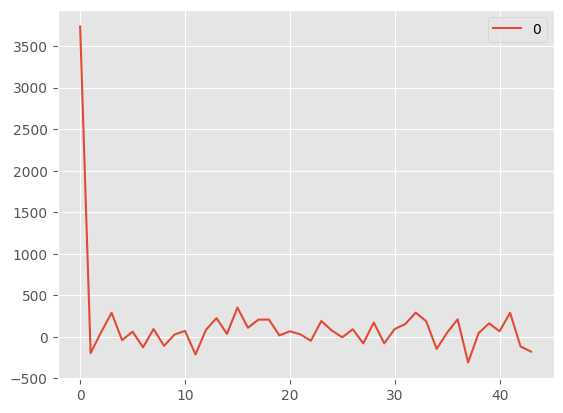

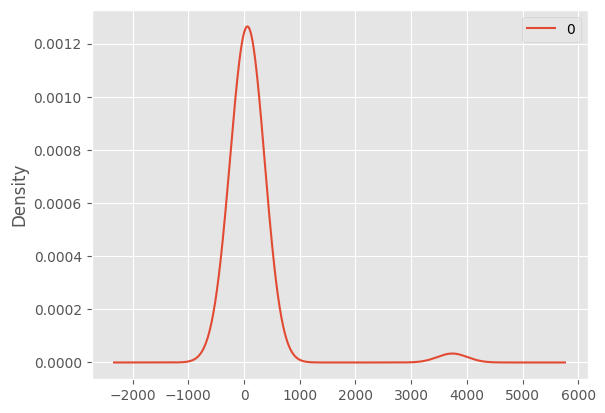

                 0
count    44.000000
mean    138.670455
std     574.508839
min    -309.000000
25%     -42.375000
50%      66.750000
75%     175.500000
max    3736.500000


In [ ]:
# Анализ остатков ARIMA(0,1,0)
residuals_4 = pd.DataFrame(model_fit_4.resid)
residuals_4.plot()
plt.show()

residuals_4.plot(kind='kde')
plt.show()
print(residuals_4.describe())

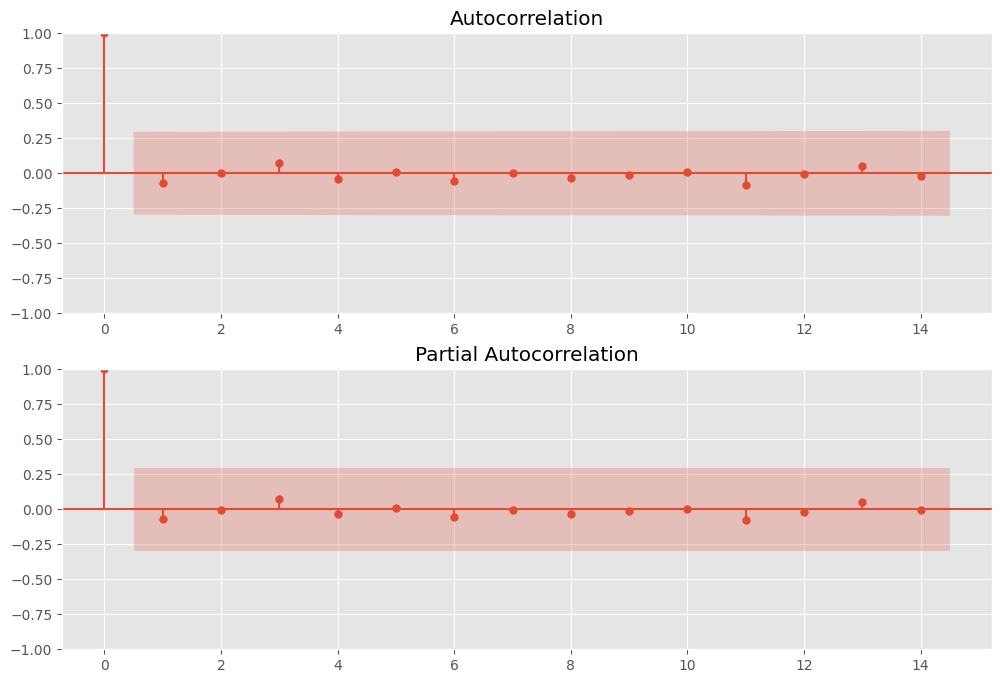

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_1, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_1, method='ywmle', lags=14, ax=plt.gca())
plt.show()

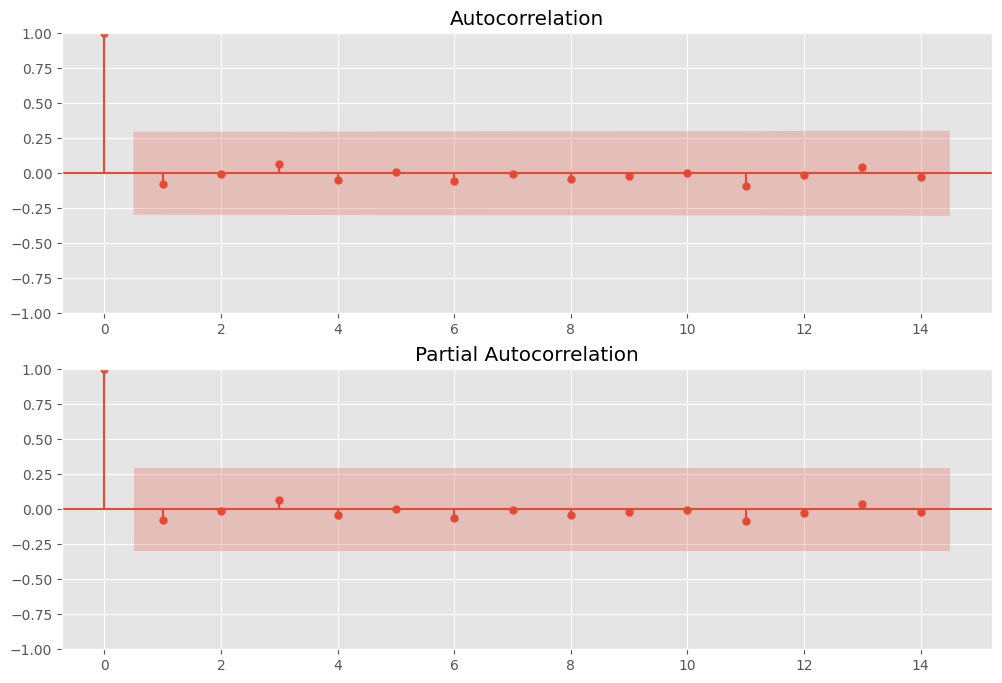

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_2, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_2, method='ywmle', lags=14, ax=plt.gca())
plt.show()

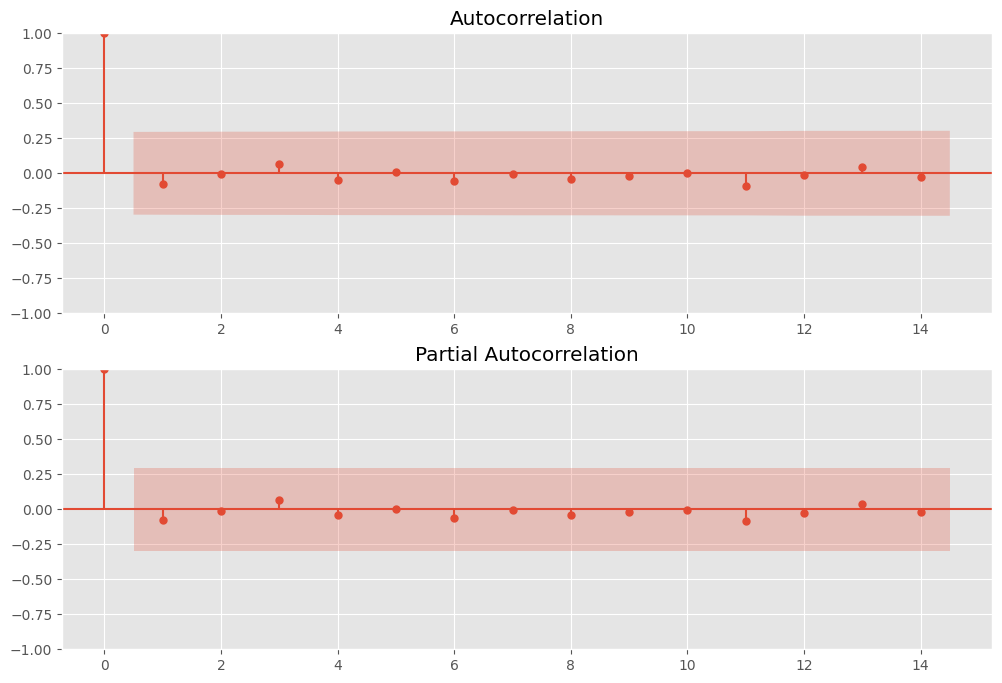

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_3, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_3, method='ywmle', lags=14, ax=plt.gca())
plt.show()

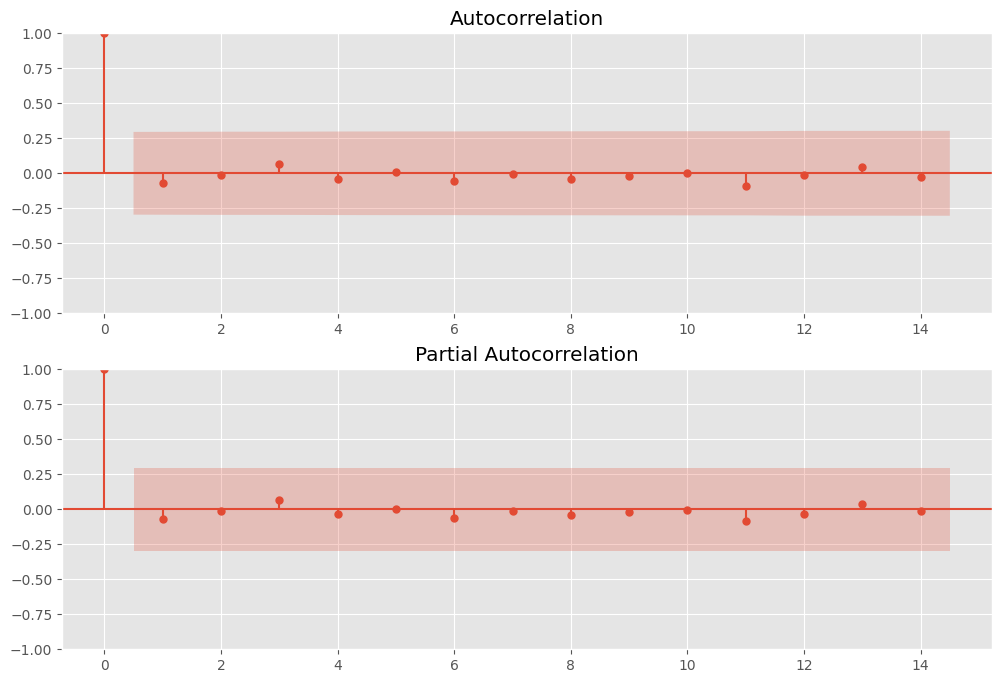

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(residuals_4, lags=14, ax=plt.gca())
plt.subplot(212)

plot_pacf(residuals_4, method='ywmle', lags=14, ax=plt.gca())
plt.show()

In [ ]:
# Сравнение моделей по AIC и BIC
comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,1)', 'ARIMA(1,1,0)', 'ARIMA(0,1,1)', 'ARIMA(0,1,0)'],
    'AIC': [model_fit_1.aic, model_fit_2.aic, model_fit_3.aic, model_fit_4.aic],
    'BIC': [model_fit_1.bic, model_fit_2.bic, model_fit_3.bic, model_fit_4.bic]})

comparison = comparison.sort_values('AIC')
print(comparison)

          Model         AIC         BIC
3  ARIMA(0,1,0)  559.564278  561.325478
0  ARIMA(1,1,1)  560.490516  565.774116
1  ARIMA(1,1,0)  561.449434  564.971835
2  ARIMA(0,1,1)  561.464475  564.986875


По результатам сравнения моделей выбираем ARIMA(0,1,0):

- Наименьшие AIC и BIC;
- Остатки во всех моделях ведут себя одинаково — ACF/PACF остатков не выявили структуры;
- Коэффициенты в ARIMA(1,1,0) и ARIMA(0,1,1) оказались незначимы.
- ARIMA(1,1,1) не выбрана, так как не обеспечивает существенного улучшения информационных критериев по сравнению с ARIMA(0,1,0), а её параметры демонстрируют слабую статистическую значимость и признаки избыточной параметризации

Модель ARIMA(0,1,0) соответствует процессу случайного блуждания (Random Walk), при котором изменения ряда носят преимущественно случайный характер.

Построим прогноз на 4 наблюдения вперед

MAPE = 2.88%


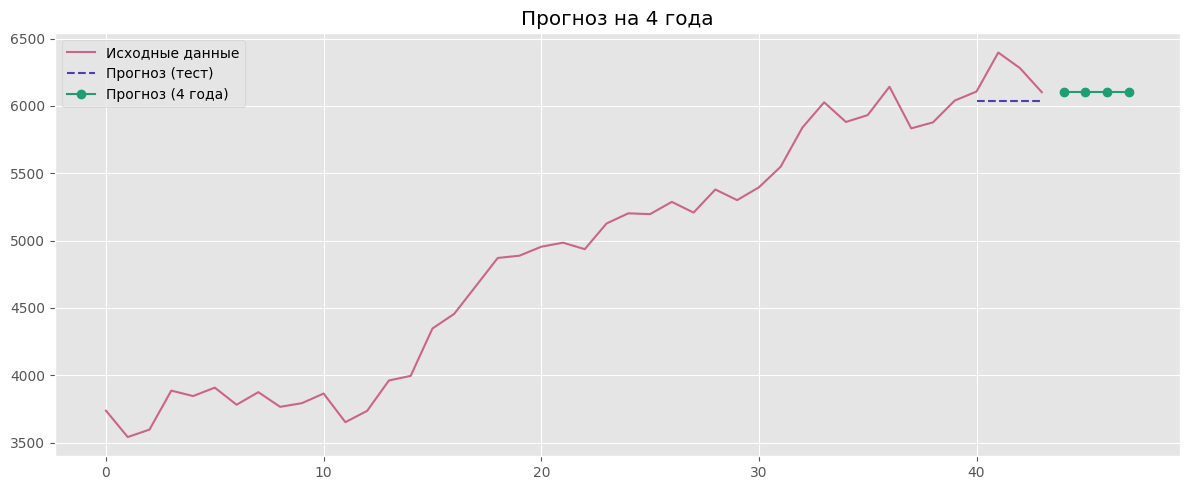

In [ ]:
# Разбивка на train/test (последние 4 наблюдения = тест)
train_2 = df_2.iloc[:-4]
test_2 = df_2.iloc[-4:]

# Обучаем модель на train
model_train = ARIMA(train_2, order=(0,1,0))
model_train_fit = model_train.fit()

# Прогноз на тестовый период
pred = model_train_fit.get_forecast(steps=4)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int(alpha=0.05)

# Метрика качества
mape = mean_absolute_percentage_error(test_2, pred_mean)
print(f'MAPE = {mape:.2%}')

# Переобучаем на всех данных → прогноз на 4 года вперёд
final_model = ARIMA(df_2, order=(0,1,0))
final_fit = final_model.fit()

forecast = final_fit.get_forecast(steps=4)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int(alpha=0.05)

# Визуализация
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df_2.index, df_2[0], color='#CB6586', label='Исходные данные')
ax.plot(test_2.index, pred_mean, '--', color='#533AB7', label='Прогноз (тест)')
ax.plot(fc_mean.index, fc_mean, 'o-', color='#1D9E75', label='Прогноз (4 года)')
ax.legend()
plt.title('Прогноз на 4 года')
plt.tight_layout()
plt.show()

In [ ]:
print('Прогноз на 4 наблюдения:')
print(fc_mean.round(2))

Прогноз на 4 наблюдения:
44    6101.5
45    6101.5
46    6101.5
47    6101.5
Name: predicted_mean, dtype: float64


По результатам тестирования модели ARIMA(0,1,0) на последних 4 наблюдениях
получили MAPE = 2.88%, что свидетельствует о высокой точности модели и хорошем качестве краткосрочного прогноза для данного временного ряда.

Прогноз на 4 года вперёд остаётся на уровне последнего наблюдения
(~6101) — это ожидаемое поведение модели случайного блуждания, которая в
качестве наилучшей оценки будущего использует последнее известное значение.

#### **Третий ряд - N1235**

In [ ]:
df_3 = pd.DataFrame(train['N1235'])
df_3.head()

,0
0,6434.0
1,5811.0
2,5815.0
3,6047.0
4,6112.0


In [ ]:
df_3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       45 non-null     object
dtypes: object(1)
memory usage: 492.0+ bytes


In [ ]:
# Переводим данные в числовой формат
df_3[0] = pd.to_numeric(df_3[0])

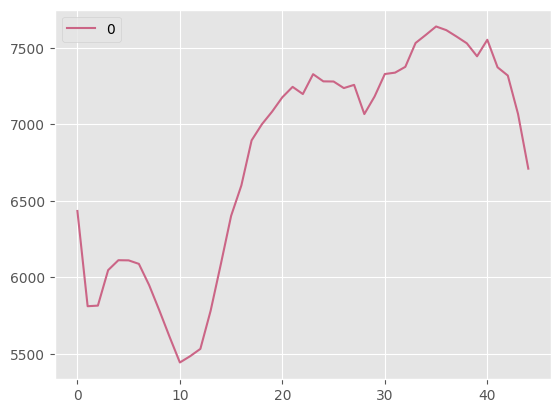

In [ ]:
df_3.plot(color = '#CB6586')
plt.show()

Временной ряд характеризуется нелинейной динамикой с несколькими фазами изменения уровня. Наблюдается отсутствие сезонности, однако присутствуют структурные изменения тренда. Скорее всего ряд нестационарный.

Проверим стационарность ряда с помощью теста Дики-Фуллера.

In [ ]:
result = adfuller(df_3[0])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

if result[1] <= 0.05:
  print('Ряд стационарен')
else:
  print('Ряд нестационарен')

ADF Statistic: -1.7284411679287386
p-value: 0.4165214998434503
Ряд нестационарен


Построим графики ACF и PACF для подбора параметров модели ARIMA.

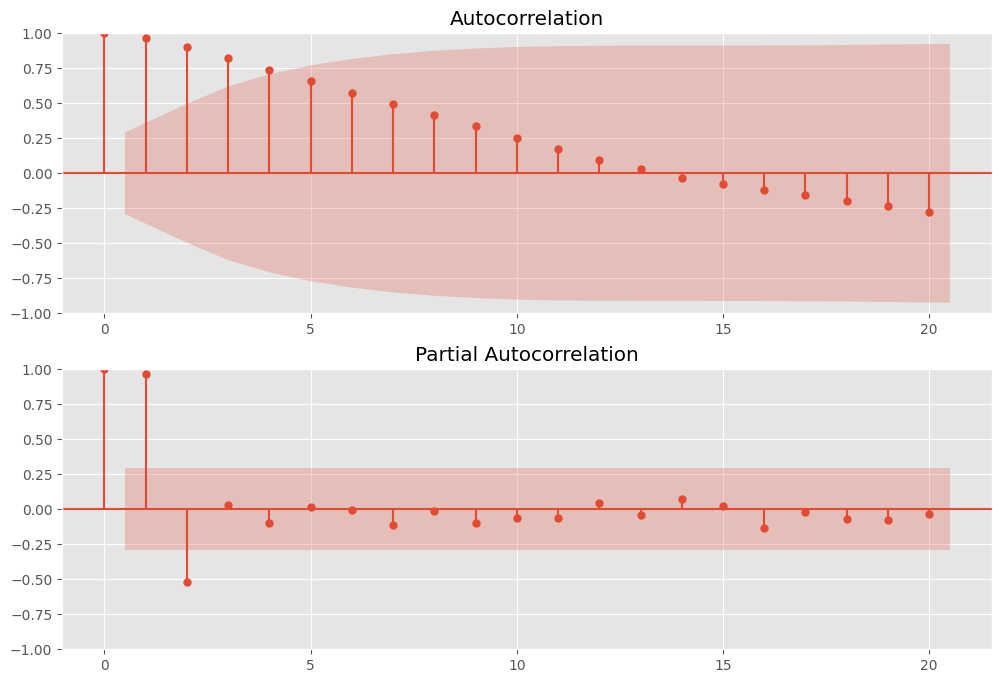

In [ ]:
plt.figure(figsize=(12,8))
plt.subplot(211)
plot_acf(df_3, lags=20, ax=plt.gca())
plt.subplot(212)

plot_pacf(df_3, method='ywmle', lags=20, ax=plt.gca())
plt.show()

По графику видно, что:

*   ACF убывает медленно и не обрывается резко, это является признаком нестационарного ряда -> d = 1
*   PACF показывает значимый пик на лагах 1 и 2, после чего все значения попадают в доверительный интервал



In [ ]:
# Модель ARIMA(1,1,0)
model_1 = ARIMA(df_3, order=(1,1,0))
model_fit_1 = model_1.fit()
print(model_fit_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   45
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -285.764
Date:                Thu, 14 May 2026   AIC                            575.527
Time:                        19:14:43   BIC                            579.095
Sample:                             0   HQIC                           576.850
                                 - 45                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4933      0.097      5.064      0.000       0.302       0.684
sigma2      2.303e+04   3484.579      6.609      0.000    1.62e+04    2.99e+04
Ljung-Box (L1) (Q):                   0.38   Jarque-

In [ ]:
# Модель ARIMA(2,1,0)
model_2 = ARIMA(df_3, order=(2,1,0))
model_fit_2 = model_2.fit()
print(model_fit_2.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   45
Model:                 ARIMA(2, 1, 0)   Log Likelihood                -285.648
Date:                Thu, 14 May 2026   AIC                            577.295
Time:                        19:14:53   BIC                            582.648
Sample:                             0   HQIC                           579.280
                                 - 45                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4388      0.103      4.247      0.000       0.236       0.641
ar.L2          0.0950      0.115      0.829      0.407      -0.130       0.319
sigma2      2.314e+04   3491.807      6.626      0.0

In [ ]:
# Модель ARIMA(2,1,1)
model_3 = ARIMA(df_3, order=(2,1,1))
model_fit_3 = model_3.fit()
print(model_fit_3.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                   45
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -285.641
Date:                Thu, 14 May 2026   AIC                            579.282
Time:                        19:15:07   BIC                            586.419
Sample:                             0   HQIC                           581.929
                                 - 45                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5428      2.628      0.207      0.836      -4.607       5.693
ar.L2          0.0453      1.232      0.037      0.971      -2.368       2.459
ma.L1         -0.1081      2.672     -0.040      0.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [ ]:
from pmdarima import auto_arima

model = auto_arima(
    df_3,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,
    seasonal=False,
    stepwise=True,
    trace=True)

print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=583.207, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=577.296, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=579.506, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=581.264, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=578.947, Time=0.12 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=578.934, Time=0.13 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=580.921, Time=0.19 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=575.527, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=577.295, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=577.290, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=577.515, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=579.282, Time=0.18 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 1.031 seconds
                               SARIMAX Results                                
Dep. Variable:       

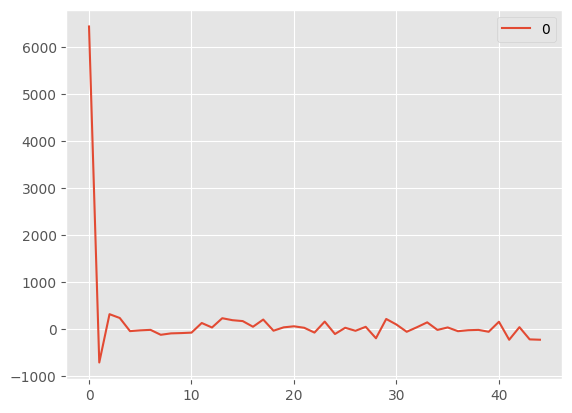

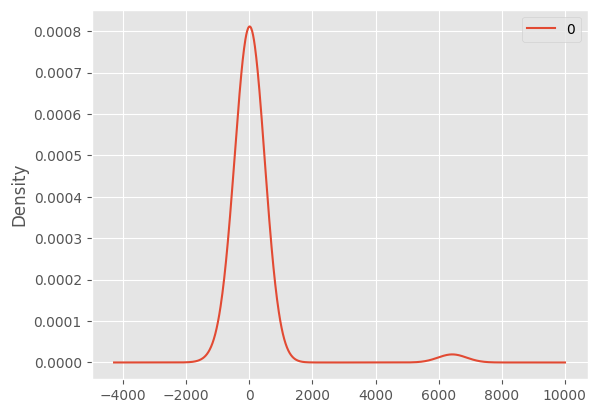

                 0
count    45.000000
mean    140.100798
std     974.102988
min    -716.737691
25%     -63.509120
50%      21.633624
75%     123.374306
max    6434.000000


In [ ]:
# Анализ остатков ARIMA(1,1,0)
residuals_1 = pd.DataFrame(model_fit_1.resid)
residuals_1.plot()
plt.show()

residuals_1.plot(kind='kde')
plt.show()
print(residuals_1.describe())

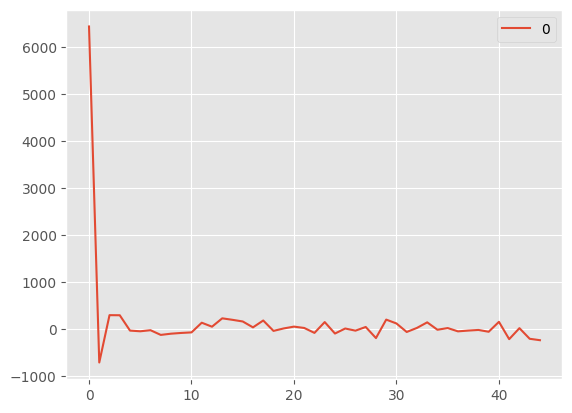

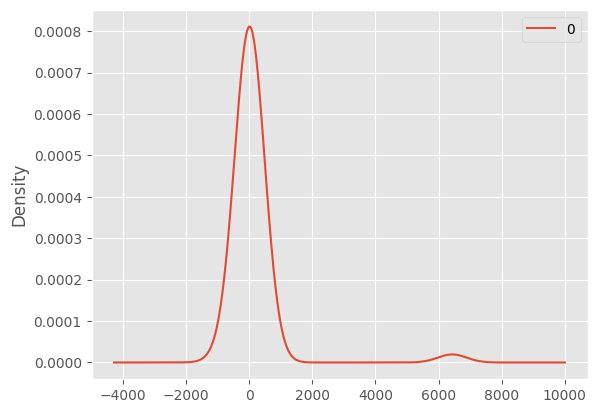

                 0
count    45.000000
mean    139.341188
std     974.151735
min    -715.395484
25%     -66.424534
50%       7.276155
75%     130.709002
max    6434.000000


In [ ]:
# Анализ остатков ARIMA(2,1,0)
residuals_2 = pd.DataFrame(model_fit_2.resid)
residuals_2.plot()
plt.show()

residuals_2.plot(kind='kde')
plt.show()
print(residuals_2.describe())

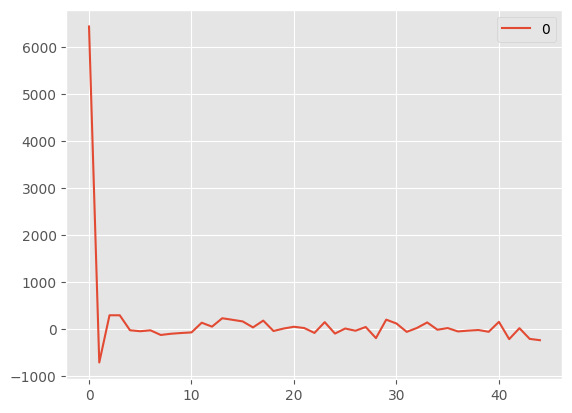

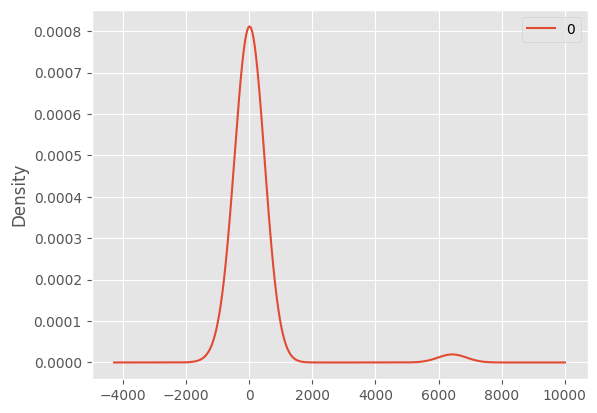

                 0
count    45.000000
mean    139.274834
std     974.147441
min    -714.857895
25%     -63.630933
50%       7.759605
75%     131.375289
max    6434.000000


In [ ]:
# Анализ остатков ARIMA(2,1,1)
residuals_3 = pd.DataFrame(model_fit_3.resid)
residuals_3.plot()
plt.show()

residuals_3.plot(kind='kde')
plt.show()
print(residuals_3.describe())

In [ ]:
# Сравнение моделей по AIC и BIC
comparison = pd.DataFrame({
    'Model': ['ARIMA(1,1,0)', 'ARIMA(2,1,0)', 'ARIMA(2,1,1)'],
    'AIC': [model_fit_1.aic, model_fit_2.aic, model_fit_3.aic],
    'BIC': [model_fit_1.bic, model_fit_2.bic, model_fit_3.bic]})

comparison = comparison.sort_values('AIC')
print(comparison)

          Model         AIC         BIC
0  ARIMA(1,1,0)  575.527070  579.095449
1  ARIMA(2,1,0)  577.295453  582.648022
2  ARIMA(2,1,1)  579.282194  586.418953


По результатам сравнения моделей выбрана модель ARIMA(1,1,0):

- Имеет минимальные значения информационных критериев AIC и BIC
- Коэффициент авторегрессии первого порядка статистически значим (p-value < 0.05)
- Остатки модели не содержат автокорреляции
- Более сложные модели не привели к улучшению качества и содержат незначимые параметры, что свидетельствует о переобучении.

Построим прогноз на 4 наблюдения вперед

MAPE = 7.30%


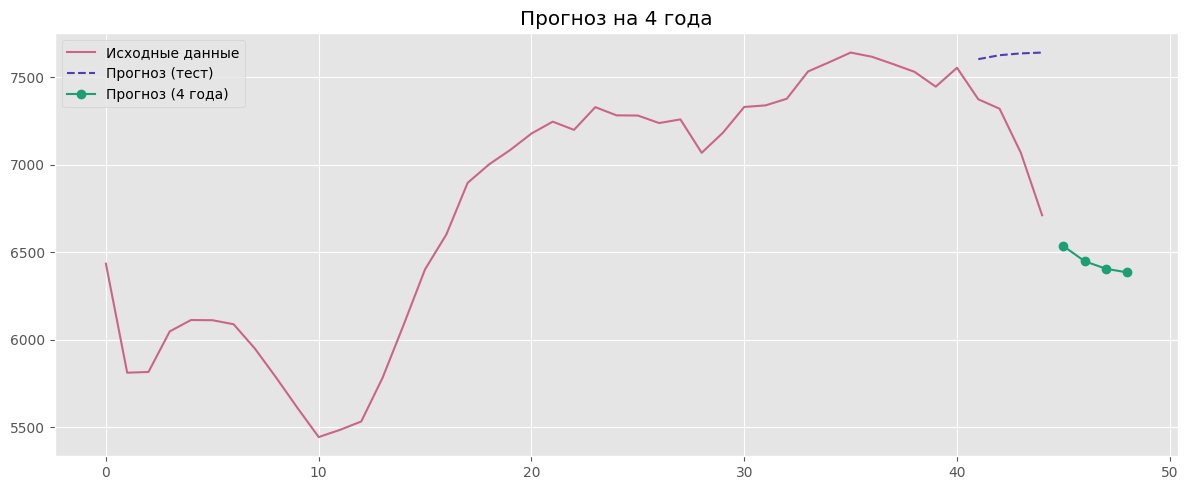

In [ ]:
# Разбивка на train/test (последние 4 наблюдения = тест)
train_3 = df_3.iloc[:-4]
test_3 = df_3.iloc[-4:]

# Обучаем модель на train
model_train = ARIMA(train_3, order=(1,1,0))
model_train_fit = model_train.fit()

# Прогноз на тестовый период
pred = model_train_fit.get_forecast(steps=4)
pred_mean = pred.predicted_mean
pred_ci = pred.conf_int(alpha=0.05)

# Метрика качества
mape = mean_absolute_percentage_error(test_3, pred_mean)
print(f'MAPE = {mape:.2%}')

# Переобучаем на всех данных → прогноз на 4 года вперёд
final_model = ARIMA(df_3, order=(1,1,0))
final_fit = final_model.fit()

forecast = final_fit.get_forecast(steps=4)
fc_mean = forecast.predicted_mean
fc_ci = forecast.conf_int(alpha=0.05)

# Визуализация
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(df_3.index, df_3[0], color='#CB6586', label='Исходные данные')
ax.plot(test_3.index, pred_mean, '--', color='#533AB7', label='Прогноз (тест)')
ax.plot(fc_mean.index, fc_mean, 'o-', color='#1D9E75', label='Прогноз (4 года)')
ax.legend()
plt.title('Прогноз на 4 года')
plt.tight_layout()
plt.show()

In [ ]:
print('Прогноз на 4 наблюдения:')
print(fc_mean.round(2))

Прогноз на 4 наблюдения:
45    6534.91
46    6448.05
47    6405.20
48    6384.07
Name: predicted_mean, dtype: float64


По результатам тестирования модели ARIMA(1,1,0) на последних 4 наблюдениях получено значение MAPE = 7.30%, что свидетельствует о достаточно хорошем качестве прогноза для данного временного ряда.

Тестовый прогноз корректно воспроизводит общий уровень ряда, однако не смог полностью предсказать резкое снижение в конце наблюдаемого периода. Это связано с тем, что модель ARIMA ориентируется преимущественно на предыдущую динамику ряда и хуже реагирует на внезапные структурные изменения.

После переобучения модели на всех доступных данных прогноз на 4 периода вперёд показывает дальнейшее умеренное снижение показателя.